In [1]:
import pyarrow.dataset as ds
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Kiểm tra chất lượng dữ liệu sau khi process tại tầng Silver

In [2]:
# Load 6 tháng Silver và bỏ qua các file report JSON
dataset = ds.dataset(
    "../data/silver", 
    format="parquet",
    partitioning="hive",
    ignore_prefixes=[".", "_", "quality"] # Bỏ qua các file bắt đầu bằng 'quality'
)

df = dataset.to_table(
    filter=ds.field("month_partition") <= "2026-03"
).to_pandas()

# 1a. Row count mỗi tháng — phải gần đúng 10k
print(df.groupby("month_partition").agg(
    rows=("email_id", "count"),
    dropped_pct=("char_count", lambda x: (x < 50).mean())
))

# 1b. Null check toàn bộ schema
print(df.isnull().sum())

# 1c. Xác nhận char_count sau truncate
print(df["char_count"].describe())
print("% > 100k chars:", (df["char_count"] > 100_000).mean())  # phải = 0

                 rows  dropped_pct
month_partition                   
2024-11          9728          0.0
2024-12          9731          0.0
2025-01          9722          0.0
2025-02          9694          0.0
2025-03          9721          0.0
2025-04          9706          0.0
2025-05          9710          0.0
2025-06          9721          0.0
2025-07          9668          0.0
2025-08          9724          0.0
2025-09          9711          0.0
2025-10          9697          0.0
2025-11          9710          0.0
2025-12          9699          0.0
2026-01          9675          0.0
2026-02          9690          0.0
2026-03          9722          0.0
email_id              0
body_clean            0
label                 0
received_at           0
char_count            0
word_count            0
n_unique_words        0
avg_word_length       0
log_chars             0
log_words             0
unique_word_ratio     0
repetition_ratio      0
complexity            0
info_density          0

1. Tính ổn định của Ingestion (Row counts & Dropped_pct)

 - Số liệu: Mỗi tháng có lượng dữ liệu rất đều đặn (dao động từ 9.694 đến 9.731 dòng). Tổng cộng có 58.302 emails cho 6 tháng. Tỷ lệ drop -- (dropped_pct) bằng 0.0.

-> Kết luận: Quá trình Ingest và Transform ổn định. Không có tháng nào bị "hụt" dữ liệu bất thường hay bị lỗi pipeline.

2. Chất lượng dữ liệu

 - Số liệu: Tất cả 21 cột (từ email_id, body_clean cho đến các đặc trưng số học như word_count, spam_keyword_count) đều có 0 giá trị NaN.

-> Kết luận: Các kỹ thuật phòng thủ (Defensive Programming) như .fillna(0) trước khi ép kiểu, và lệnh dropna trong hàm `run_quality_check` hoạt động tốt. Dataframe sẵn sàng đưa vào thuật toán Machine Learning nào mà không lo bị crash.

3. Logic làm sạch hoạt động chính xác (Min Char Count)

 - Số liệu: min = 5.000000e+01 (Chính xác 50 ký tự).

-> Kết luận: Điều này chứng minh block code loại bỏ email ngắn (MIN_CHAR_COUNT = 50) trong silver_transform.py đã hoạt động thành công. Những email rác quá ngắn không có giá trị phân loại đã được làm sạch.

4. Chiến thuật "Truncate Outlier" là hoàn toàn chính xác

 - Số liệu: * Trung vị (50%) là 748 ký tự, nhưng trung bình (mean) bị kéo lên tới 1.845 ký tự.

 - Max lên tới 1.107387e+07 (11 triệu ký tự).

 - Tỷ lệ email > 100k ký tự chỉ là 0.000308 (~0.03% của tập dữ liệu, tương đương khoảng 18 emails).

-> Kết luận: Cột char_count vẫn giữ được con số 11 triệu là rất tốt (vì nó phản ánh đúng độ dài thật của file gốc để đưa vào model làm feature). Đồng thời, vì số lượng email dài > 100k chars chỉ chiếm 0.03%, quyết định cắt cụt (truncate) phần text body_clean ở 100k ký tự trong file silver_transform.py là hợp lý.

### 2. Phân phối nhãn

label
0    0.530616
1    0.469384
Name: proportion, dtype: float64


<Axes: title={'center': 'Spam ratio by month'}, xlabel='month_partition'>

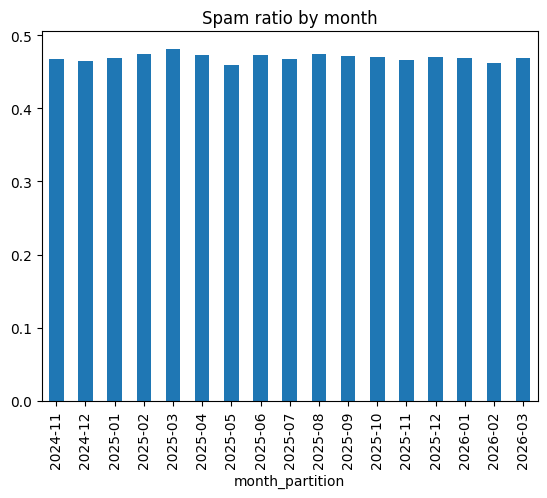

In [3]:
# 2a. Tổng thể
print(df["label"].value_counts(normalize=True))

# 2b. Theo từng tháng — phát hiện drift sớm
df.groupby("month_partition")["label"].mean().plot(
    kind="bar", title="Spam ratio by month"
)

- Phân phối đồng đều

### 3. Feature Distribution (spam vs ham)

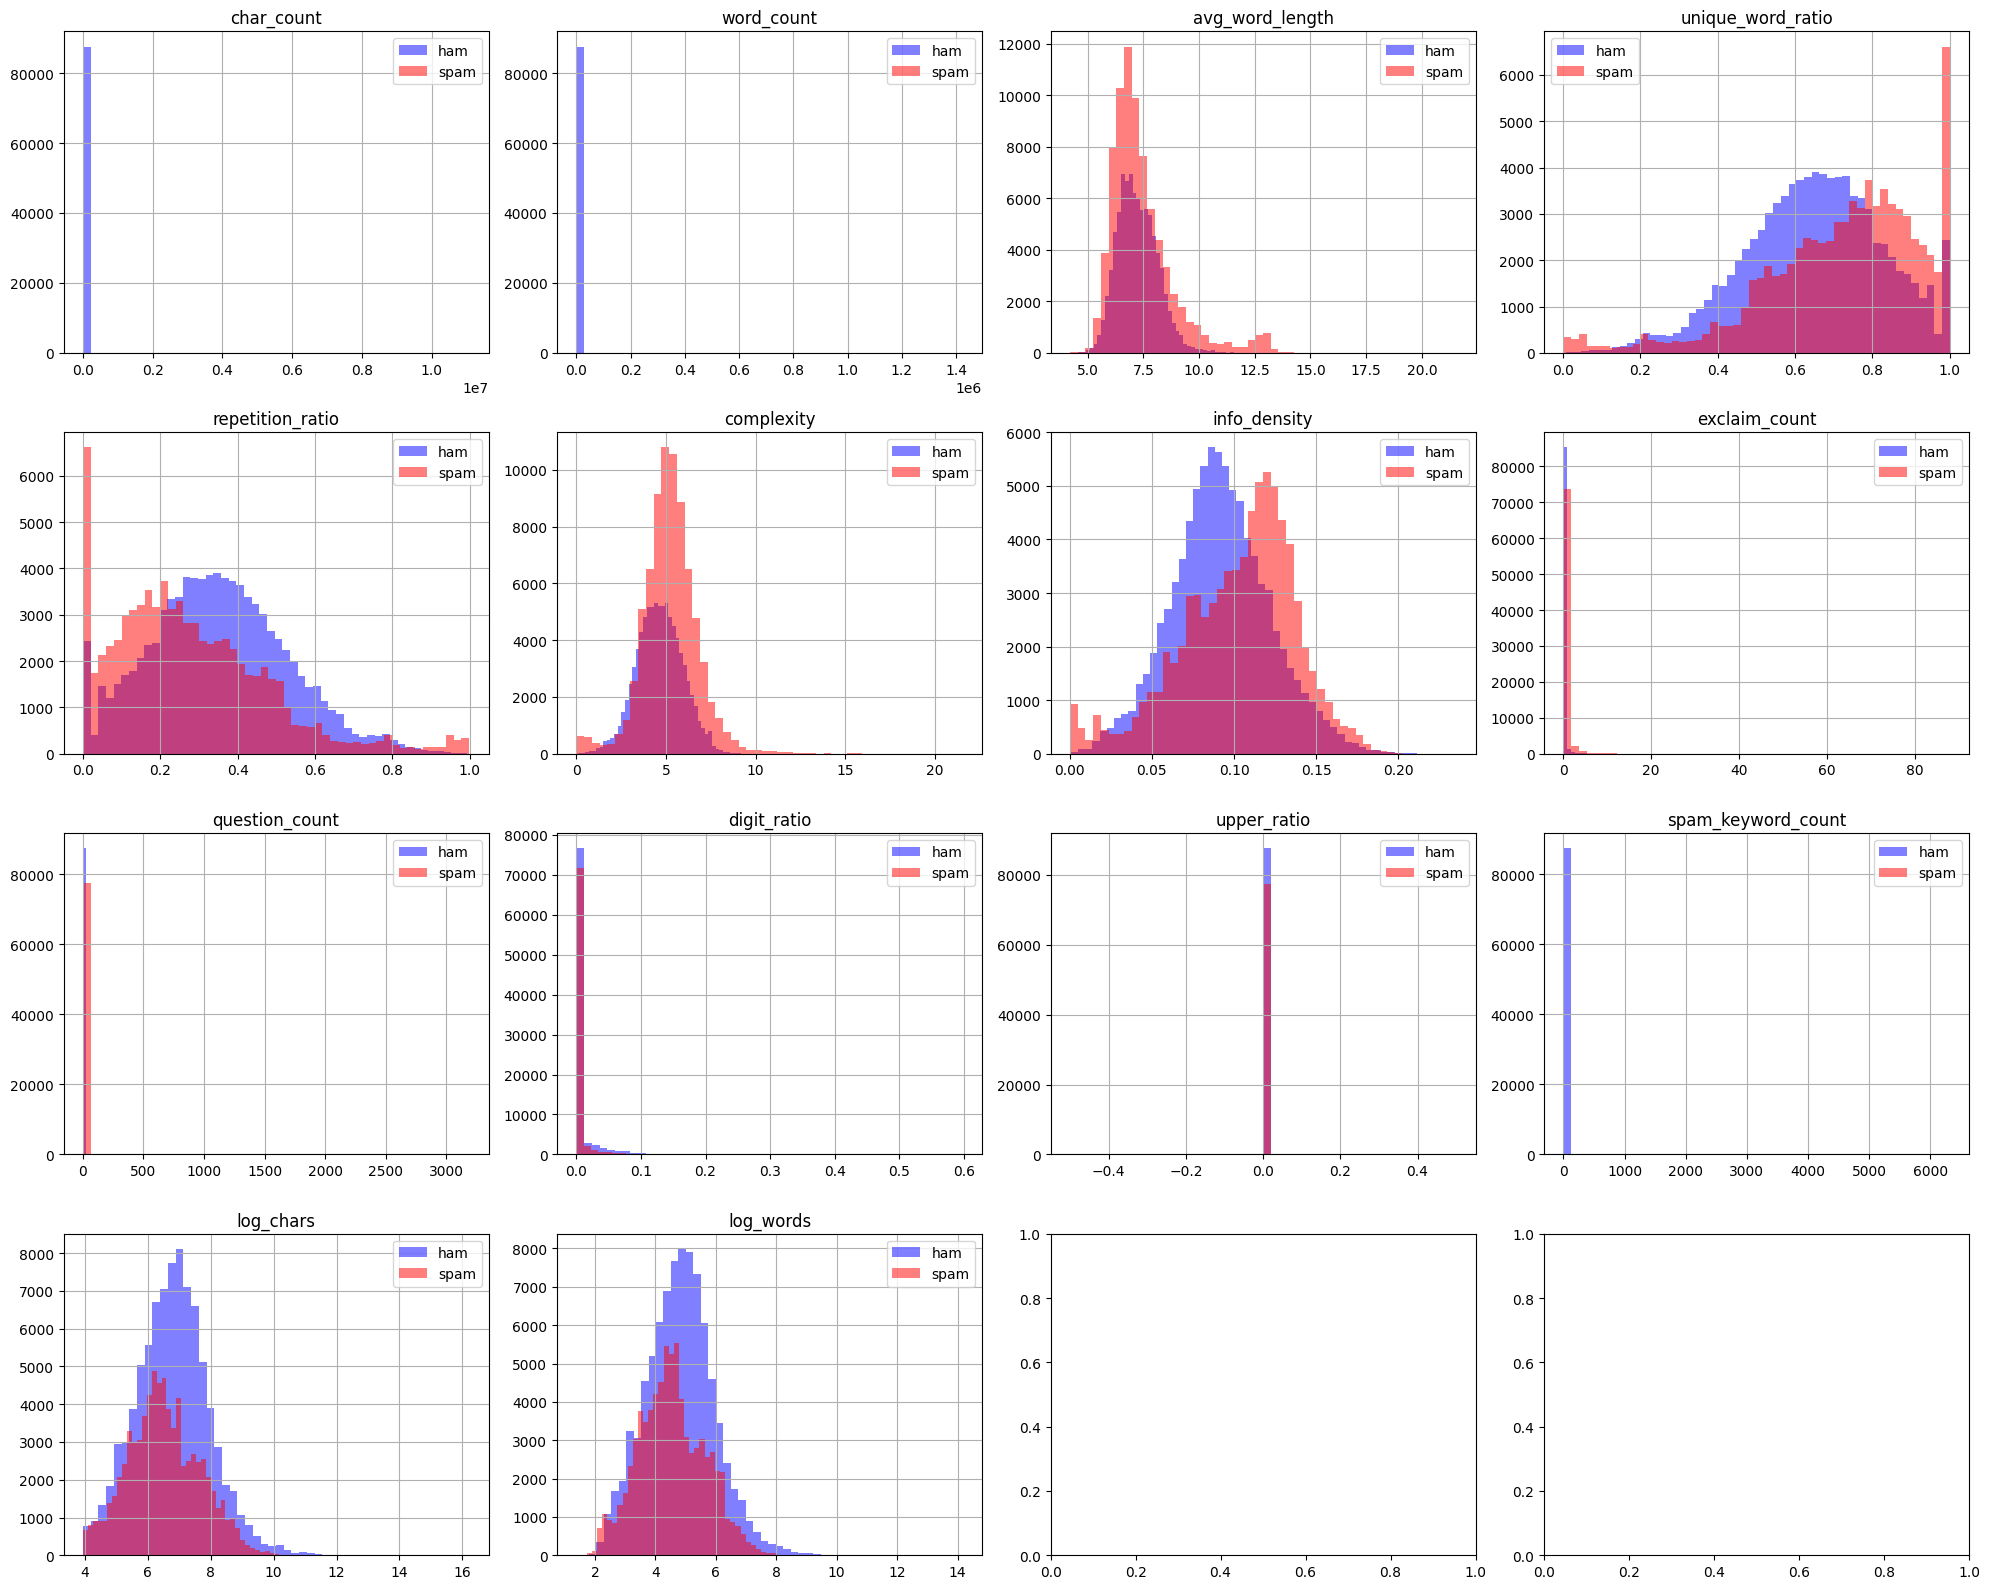

In [4]:
numeric_features = [
    "char_count", "word_count", "avg_word_length", "unique_word_ratio",
    "repetition_ratio", "complexity", "info_density",
    "exclaim_count", "question_count", "digit_ratio", "upper_ratio",
    "spam_keyword_count", "log_chars", "log_words",
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, feat in zip(axes.flat, numeric_features):
    df[df["label"]==0][feat].hist(ax=ax, alpha=0.5, bins=50, label="ham", color="blue")
    df[df["label"]==1][feat].hist(ax=ax, alpha=0.5, bins=50, label="spam", color="red")
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()

**1. Nhóm Đặc trưng "Tử huyệt" (Nên loại bỏ ở tầng Gold)**

- Nhìn vào hàng dưới cùng và một số biểu đồ ở hàng 3: upper_ratio, digit_ratio, exclaim_count, question_count, spam_keyword_count.

- Hiện tượng: Phân phối của cả Spam và Ham đều dồn thành một cột thẳng đứng duy nhất ở mốc 0.

Ý nghĩa thực tế: Khẳng định lại phát hiện ở tầng Bronze. Bộ dataset này đã bị xử lý triệt để từ đầu (viết thường toàn bộ, xóa dấu câu, và thay số bằng escapenumber). Riêng spam_keyword_count bằng 0 có thể do các từ khóa định nghĩa không tồn tại trong datatset này.

-> Hành động: Xóa 5 cột này trước khi đưa vào huấn luyện mô hình. Giữ lại chúng chỉ làm tăng số chiều dữ liệu (Curse of Dimensionality) và gây nhiễu.

**2. Log-scale (Xử lý Outlier)**

Nhìn vào sự khác biệt giữa `char_count` / `word_count` (Hàng 1) và `log_chars / log_words` (Hàng 4).

  - Hiện tượng: Ở dạng thô (Hàng 1), dữ liệu bị bóp nghẹt vào thùng (bin) đầu tiên do bị kéo giãn bởi các email quá dài (Right-skewed). Ở dạng Log (Hàng 4), dữ liệu "bung" ra thành hình chuông (Normal-like distribution).

  - Ý nghĩa thực tế: Biểu đồ Log cho thấy rõ ràng: Email Ham (xanh) có xu hướng dài hơn một chút xíu so với Spam (đỏ) - đỉnh của màu xanh nằm dịch về bên phải.

-> Hành động: Sử dụng 2 cột log_chars và log_words cho tầng Gold. Bỏ đi cột thô để thuật toán hội tụ nhanh hơn.

**3. Nhóm Đặc trưng quan trọng (Killer Features)**

Đây là những cột cho thấy sự khác biệt rõ nét nhất giữa hành vi viết thư rác và thư thường:

- `unique_word_ratio` & `repetition_ratio`:
 
  - Quan sát: Đặc trưng mạnh nhất của bạn! Spam (đỏ) có một cột đột biến (spike) cực cao ở mốc 1.0 của unique_word_ratio (và mốc 0.0 của repetition_ratio). Trong khi đó, Ham (xanh) phân phối thoai thoải ở mốc 0.6 - 0.8.

  -> Ý nghĩa: Tỷ lệ unique = 1.0 nghĩa là không có từ nào lặp lại. Điều này tố cáo hành vi của Spammer: Chúng thường gửi những email rất ngắn chứa một mớ từ khóa (keyword stuffing) hoặc chỉ 1 đường link, không có cấu trúc ngữ pháp tự nhiên (văn phong tự nhiên luôn có sự lặp lại của giới từ, mạo từ như a, an, the, in, on).

- `avg_word_length`:

  ` Quan sát: Spam chụm lại thành một đỉnh cực nhọn ở mốc 6-7 ký tự/từ. Ham thì trải dài hơn.

  -> Ý nghĩa: Từ vựng của Spam trong dataset này có độ dài rất đồng đều, thiếu đi sự phong phú về các từ nối ngắn hoặc các thuật ngữ chuyên ngành siêu dài như trong email công việc.

- `info_density`:

  - Quan sát: Màu đỏ lệch hẳn sang phải so với màu xanh. Mật độ thông tin của thư rác cao hơn hẳn.

### 4. Correlation

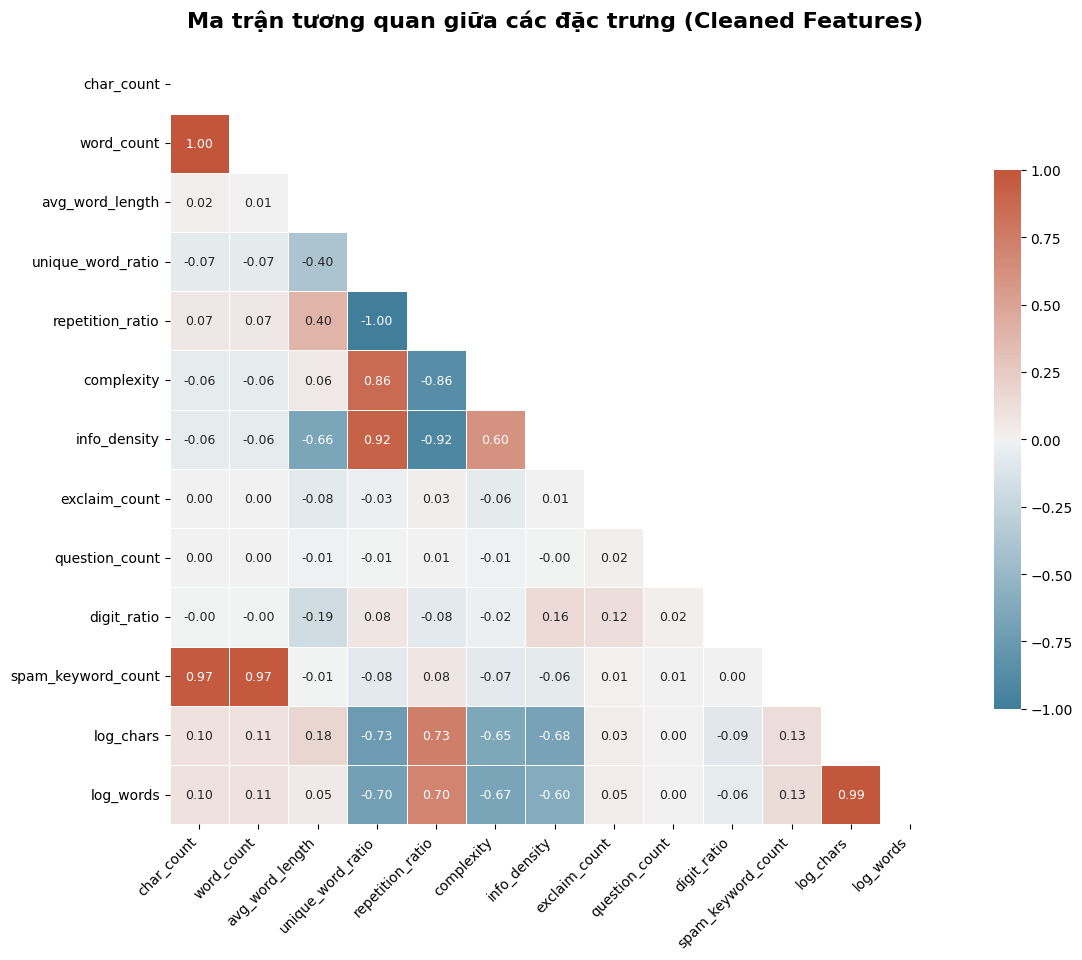


CÁC CẶP CÓ TƯƠNG QUAN RẤT CAO (> 0.9):


,Feature 1,Feature 2,Correlation
0,char_count,word_count,0.999425
6,log_chars,log_words,0.991416
2,word_count,spam_keyword_count,0.970585
1,char_count,spam_keyword_count,0.967866
4,unique_word_ratio,info_density,0.919017
5,repetition_ratio,info_density,-0.919017
3,unique_word_ratio,repetition_ratio,-1.000000


In [5]:
# 1. Lọc bỏ các cột có biến thiên bằng 0 (std = 0)
# Dựa trên EDA trước đó, các cột như upper_ratio, exclaim_count... thường toàn bằng 0
valid_features = [f for f in numeric_features if df[f].std() > 0]

# 2. Tính toán ma trận tương quan
corr = df[valid_features].corr()

# 3. Tạo Mask để ẩn nửa trên của biểu đồ (tránh lặp lại thông tin)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Thiết lập cấu hình đồ họa
plt.figure(figsize=(14, 10))
cmap = sns.diverging_palette(230, 20, as_cmap=True) # Màu xanh - trắng - đỏ 

# 5. Vẽ Heatmap
sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, center=0,
    annot=True, fmt=".2f", # Hiện số với 2 chữ số thập phân
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7}, # Thu nhỏ thanh chú thích màu
    annot_kws={"size": 9}    # Điều chỉnh cỡ chữ số
)

plt.title('Ma trận tương quan giữa các đặc trưng (Cleaned Features)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

# Phân tích High Correlation
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.9:
            high_corr.append({
                "Feature 1": corr.columns[i], 
                "Feature 2": corr.columns[j], 
                "Correlation": corr.iloc[i,j]
            })

if high_corr:
    print("\nCÁC CẶP CÓ TƯƠNG QUAN RẤT CAO (> 0.9):")
    display(pd.DataFrame(high_corr).sort_values(by="Correlation", ascending=False))
else:
    print("\Không có cặp đặc trưng nào quá tương quan.")

### 6. Phân tích feature `has_escapenumber`

In [6]:
# Tỉ lệ xuất hiện theo label
print(df.groupby("label")["has_escapenumber"].mean())
# Nếu spam >> ham → feature mạnh, giữ
# Nếu gần bằng nhau → feature yếu

# Confusion nếu bỏ feature này
from sklearn.metrics import mutual_info_score
mi = mutual_info_score(df["label"], df["has_escapenumber"])
print(f"Mutual information: {mi:.4f}")

label
0    0.743705
1    0.663500
Name: has_escapenumber, dtype: float64
Mutual information: 0.0039


-> Feature không có giá trị, loại bỏ

### 7. Baseline model trên Numerical Features

- Mục đích: Xác nhận numeric features alone đạt bao nhiêu F1. Nếu đã > 0.90 thì Gold không nhất thiết phải dùng TF-IDF. Nếu chỉ 0.7-0.8 thì Gold cần thêm `body_clean` text features.

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

feature_cols = [
    "char_count", "word_count", "avg_word_length",
    "unique_word_ratio", "repetition_ratio", "complexity",
    "exclaim_count", "question_count", "digit_ratio", "upper_ratio",
    "spam_keyword_count", "has_escapenumber", "log_chars", "log_words",
]

X = df[feature_cols].fillna(0)
y = df["label"]

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: F1 = 0.6425 ± 0.0025
Random Forest: F1 = 0.7764 ± 0.0009
